Filter out known actives that were used to build the QSAR model, we already know the affinity of those compounds and do not need to further study them.

In [1]:
import pandas as pd

known_actives = pd.read_csv("data/DATASET_ic50_cleaned_compounds.csv")
id_list = known_actives["molecule_chembl_id"].tolist()

In [ ]:
# cli commands for quick manipulation of huge csv file
!zcat predictions/predictions_minimal.csv.gz | head -n 1 > predictions/chembl_screen_sorted.csv
!zcat predictions/predictions_minimal.csv.gz | tail -n +2 | sort -t',' -k5,5r >> predictions/chembl_screen_sorted.csv
!cat predictions/chembl_screen_sorted.csv | head -n 5001 > predictions/chembl_screen_top_5k

In [2]:
chembl_screen_sorted = pd.read_csv("predictions/chembl_screen_sorted.csv")

In [3]:
len(chembl_screen_sorted)

2708689

In [4]:
chembl_screen_filtered = chembl_screen_sorted[~chembl_screen_sorted["compound_name"].isin(id_list)]

In [5]:
len(chembl_screen_filtered)

2708268

In [6]:
chembl_screen_filtered.head()

,compound_name,input_smiles,standardized_smiles,valid,pIC50_pred,inside_ad,knn_similarity,reliability
0,CHEMBL5428596,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5C[C@H]6CC[C@@H...,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5C[C@H]6CC[C@@H...,True,9.288634,True,0.640722,High
3,CHEMBL5315142,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CC6CCC(C5)N6)n...,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CC6CCC(C5)N6)n...,True,9.214940,True,0.686582,High
4,CHEMBL5315168,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CC6CCC(C5)N6)n...,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CC6CCC(C5)N6)n...,True,9.214940,True,0.686582,High
7,CHEMBL5569798,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CCCC(C#N)C5)nc...,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CCCC(C#N)C5)nc...,True,9.103165,True,0.615259,High
9,CHEMBL5286333,[2H]C1([2H])CC[C@@]2(COc3nc(N4CC5CCC(C4)N5)c4c...,[2H]C1([2H])CC[C@@]2(COc3nc(N4CC5CCC(C4)N5)c4c...,True,9.051933,True,0.669467,High


In [7]:
chembl_screen_filtered.tail()

,compound_name,input_smiles,standardized_smiles,valid,pIC50_pred,inside_ad,knn_similarity,reliability
2708681,CHEMBL4455946,O=c1[nH]c(-c2ccccc2)nc2ccsc12,O=c1[nH]c(-c2ccccc2)nc2ccsc12,True,5.072824,False,0.261260,Low
2708682,CHEMBL2376607,Cc1[nH]c2ccccc2c1C1c2ccccc2C(=O)N1CC(=O)NO,Cc1[nH]c2ccccc2c1C1c2ccccc2C(=O)N1CC(=O)NO,True,5.051044,True,0.355114,High
2708683,CHEMBL4103373,CC(C)(C)C[C@@H]1NC(=O)[C@@H](Cc2ccccc2)NC(=O)[...,CC(C)(C)C[C@@H]1NC(=O)[C@@H](Cc2ccccc2)NC(=O)[...,True,5.030598,True,0.369541,High
2708685,CHEMBL4531663,O=C(O)c1ccnc(-c2nc3ccsc3c(=O)[nH]2)c1,O=C(O)c1ccnc(-c2nc3ccsc3c(=O)[nH]2)c1,True,4.997176,True,0.302276,High
2708687,CHEMBL4571057,O=c1[nH]c(-c2cc(Br)ccn2)nc2ccsc12,O=c1[nH]c(-c2cc(Br)ccn2)nc2ccsc12,True,4.891688,False,0.289797,Low


In [8]:
chembl_screen_filtered = chembl_screen_filtered[(chembl_screen_filtered["valid"]) & (chembl_screen_filtered["inside_ad"])]

In [9]:
len(chembl_screen_filtered)

1746378

In [10]:
# This creates a DataFrame containing only the rows that are duplicates
duplicates = chembl_screen_filtered[chembl_screen_filtered.duplicated(subset=["standardized_smiles"], keep=False)]

# Sort by SMILES to see the identical pairs next to each other
duplicates_sorted = duplicates.sort_values("standardized_smiles")

In [11]:
duplicates_sorted.head()

,compound_name,input_smiles,standardized_smiles,valid,pIC50_pred,inside_ad,knn_similarity,reliability
721882,CHEMBL1179931,CCCCc1oc2ccccc2c1C(=O)c1cc(I)c(OCC[N+](CC)(CC)...,CCCCc1oc2ccccc2c1C(=O)c1cc(I)c(OCC[N+](CC)(CC)...,True,5.786674,True,0.339110,High
721881,CHEMBL105041,CCCCc1oc2ccccc2c1C(=O)c1cc(I)c(OCC[N+](CC)(CC)...,CCCCc1oc2ccccc2c1C(=O)c1cc(I)c(OCC[N+](CC)(CC)...,True,5.786674,True,0.339110,High
27815,CHEMBL2219627,CCO/N=C(\C(=O)N[C@@H]1C(=O)N2C(C(=O)[O-])=C(C[...,CCO/N=C(\C(=O)N[C@@H]1C(=O)N2C(C(=O)[O-])=C(C[...,True,6.493081,True,0.408236,High
27816,CHEMBL574130,CCO/N=C(\C(=O)N[C@@H]1C(=O)N2C(C(=O)[O-])=C(C[...,CCO/N=C(\C(=O)N[C@@H]1C(=O)N2C(C(=O)[O-])=C(C[...,True,6.493081,True,0.408236,High
2497,CHEMBL4646526,CC[N+]1=C(/C=C/C=C/C=C2/N(CCCCCC(=O)NC34CCC(CO...,CC[N+]1=C(/C=C/C=C/C=C2/N(CCCCCC(=O)NC34CCC(CO...,True,6.951196,True,0.429226,High


In [ ]:
duplicates_sorted["input_smiles"].values

array(['CCCCc1oc2ccccc2c1C(=O)c1cc(I)c(OCC[N+](CC)(CC)COP(=O)(O)O)c(I)c1',
       'CCCCc1oc2ccccc2c1C(=O)c1cc(I)c(OCC[N+](CC)(CC)COP(=O)(O)O)c(I)c1.O=C([O-])C(F)(F)F',
       'CCO/N=C(\\C(=O)N[C@@H]1C(=O)N2C(C(=O)[O-])=C(C[n+]3cccc4c3ncn4CCCNC)CS[C@H]12)c1nsc(N)n1',
       'CCO/N=C(\\C(=O)N[C@@H]1C(=O)N2C(C(=O)[O-])=C(C[n+]3cccc4c3ncn4CCCNC)CS[C@H]12)c1nsc(N)n1.O=S(=O)(O)O',
       'CC[N+]1=C(/C=C/C=C/C=C2/N(CCCCCC(=O)NC34CCC(COc5ncc(-c6ccnc7[nH]ncc67)cc5C)(CC3)CC4)c3ccc(S(=O)(=O)O)cc3C2(C)C)C(C)(C)c2cc(S(=O)(=O)O)ccc21.O=C([O-])C(F)(F)F',
       'CC[N+]1=C(/C=C/C=C/C=C2/N(CCCCCC(=O)NC34CCC(COc5ncc(-c6ccnc7[nH]ncc67)cc5C)(CC3)CC4)c3ccc(S(=O)(=O)O)cc3C2(C)C)C(C)(C)c2cc(S(=O)(=O)O)ccc21',
       'CO/N=C(/C(=O)N[C@@H]1C(=O)N2C(C(=O)[O-])=C(C[n+]3ccn4ncccc43)CS[C@H]12)c1nsc(N)n1',
       'CO/N=C(/C(=O)N[C@@H]1C(=O)N2C(C(=O)[O-])=C(C[n+]3ccn4ncccc43)CS[C@H]12)c1nsc(N)n1.O=S(=O)(O)O',
       'CO/N=C(\\C(=O)N[C@@H]1C(=O)N2C(C(=O)[O-])=C(C[n+]3cccc4c3CCC4)CS[C@H]12)c1csc(N)n1',
       'CO/N=C(

In [13]:
chembl_screen_filtered = chembl_screen_filtered[~chembl_screen_filtered['input_smiles'].str.contains('\.', na=False)]

In [16]:
len(chembl_screen_filtered)

1696690

In [17]:
#check for duplicates
duplicates = chembl_screen_filtered[chembl_screen_filtered.duplicated(subset=["standardized_smiles"], keep=False)]
len(duplicates)

0

In [19]:
import datamol as dm

chembl_screen_filtered["clean_mols"] = dm.parallelized(dm.to_mol, chembl_screen_filtered["standardized_smiles"].values, n_jobs=-1)

In [20]:
# Check which values are NaN
is_missing = chembl_screen_filtered["clean_mols"].isna()

# Count how many failed standardization
print(f"Number of failed molecules: {is_missing.sum()}")

Number of failed molecules: 0


In [21]:
from rdkit.Chem import rdMolDescriptors, Crippen, Lipinski, QED

def get_extended_descriptors(mol):
    """Function to calculate 8 descriptors for a single molecule."""
    if mol is None:
        return {col: None for col in ["MW", "ClogP", "TPSA", "HBD", "HBA", "QED", "FractionCsp3", "NumAromaticRings"]}
    
    return {
        "MW": rdMolDescriptors.CalcExactMolWt(mol),
        "ClogP": Crippen.MolLogP(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "HBD": Lipinski.NumHDonors(mol),
        "HBA": Lipinski.NumHAcceptors(mol),
        "QED": QED.qed(mol),
        "FractionCsp3": rdMolDescriptors.CalcFractionCSP3(mol),
        "NumAromaticRings": Lipinski.NumAromaticRings(mol)
    }

# Run parallel processing on the column containing RDKit Mol objects
results = dm.parallelized(get_extended_descriptors, chembl_screen_filtered["clean_mols"].values, n_jobs=-1)

In [22]:
desc_df = pd.DataFrame(results)
desc_df.isna().values.any()

False

In [23]:
df1 = chembl_screen_filtered.reset_index(drop=True)
df2 = desc_df.reset_index(drop=True)

In [24]:
# Merge back to the main dataframe
df = pd.concat([df1, df2], axis=1)

In [25]:
df.head()

,compound_name,input_smiles,standardized_smiles,valid,pIC50_pred,inside_ad,knn_similarity,reliability,clean_mols,MW,ClogP,TPSA,HBD,HBA,QED,FractionCsp3,NumAromaticRings
0,CHEMBL5428596,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5C[C@H]6CC[C@@H...,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5C[C@H]6CC[C@@H...,True,9.288634,True,0.640722,High,<rdkit.Chem.rdchem.Mol object at 0x15294cd10>,803.397060,7.06910,124.97,3,10,0.151540,0.565217,4
1,CHEMBL5315142,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CC6CCC(C5)N6)n...,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CC6CCC(C5)N6)n...,True,9.214940,True,0.686582,High,<rdkit.Chem.rdchem.Mol object at 0x1522a0680>,600.246059,4.70590,86.64,2,8,0.319044,0.424242,4
2,CHEMBL5315168,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CC6CCC(C5)N6)n...,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CC6CCC(C5)N6)n...,True,9.214940,True,0.686582,High,<rdkit.Chem.rdchem.Mol object at 0x15294d0d0>,600.246059,4.70590,86.64,2,8,0.319044,0.424242,4
3,CHEMBL5569798,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CCCC(C#N)C5)nc...,C#Cc1c(F)ccc2cc(O)cc(-c3ncc4c(N5CCCC(C#N)C5)nc...,True,9.103165,True,0.615259,High,<rdkit.Chem.rdchem.Mol object at 0x152403ba0>,598.230409,5.50528,98.40,1,8,0.300797,0.393939,4
4,CHEMBL5286333,[2H]C1([2H])CC[C@@]2(COc3nc(N4CC5CCC(C4)N5)c4c...,[2H]C1([2H])CC[C@@]2(COc3nc(N4CC5CCC(C4)N5)c4c...,True,9.051933,True,0.669467,High,<rdkit.Chem.rdchem.Mol object at 0x15239d440>,602.258612,4.70590,86.64,2,8,0.318151,0.424242,4


In [26]:
df["HBD_HBA"] = df["HBD"] + df["HBA"]
descriptors = ["MW", "ClogP", "TPSA", "HBD", "HBA", "QED", "FractionCsp3", "NumAromaticRings"]
print("Missing values per column:")
print(df[descriptors].isna().sum())

Missing values per column:
MW                  0
ClogP               0
TPSA                0
HBD                 0
HBA                 0
QED                 0
FractionCsp3        0
NumAromaticRings    0
dtype: int64


In [33]:
df.to_csv("predictions/chembl_screen_results_with_properties.csv")

In [39]:
filtered_df_7 = df[(df["MW"]<=800) & (df["ClogP"]<=7) & (df["pIC50_pred"] >= 7)]
filtered_df_6 = df[(df["MW"]<=800) & (df["ClogP"]<=7) & (df["pIC50_pred"] >= 6)]

In [46]:
filtered_df_6_5 = df[(df["MW"]<=800) & (df["ClogP"]<=7) & (df["pIC50_pred"] >= 6.9)]

In [41]:
print(filtered_df_7.shape)
print(filtered_df_6.shape)

(704, 18)
(229496, 18)


In [47]:
print(filtered_df_6_5.shape)

(1244, 18)


In [48]:
df = filtered_df_6_5

In [51]:
df.tail()

,compound_name,input_smiles,standardized_smiles,valid,pIC50_pred,inside_ad,knn_similarity,reliability,clean_mols,MW,ClogP,TPSA,HBD,HBA,QED,FractionCsp3,NumAromaticRings,HBD_HBA,HB_total
2824,CHEMBL1223834,Cn1c(CCC(=O)CCc2ccccc2)cc2c1[C@@H]1Oc3c(O)ccc4...,Cn1c(CCC(=O)CCc2ccccc2)cc2c1[C@@H]1Oc3c(O)ccc4...,True,6.900776,True,0.439207,High,<rdkit.Chem.rdchem.Mol object at 0x152a6f470>,538.283158,4.56430,74.93,2,6,0.439833,0.500000,3,8,8
2825,CHEMBL3605170,CN1C[C@@H](c2ccco2)[C@@]2(N=C(c3ccccc3)OC2=O)[...,CN1C[C@@H](c2ccco2)[C@@]2(N=C(c3ccccc3)OC2=O)[...,True,6.900693,True,0.423328,High,<rdkit.Chem.rdchem.Mol object at 0x152a6f510>,503.184506,4.49330,75.35,0,6,0.383750,0.193548,4,6,6
2827,CHEMBL6052603,Cc1ccc(-n2nc3c(c2NC(=O)CS(C)(=O)=O)C(=O)N[C@@]...,Cc1ccc(-n2nc3c(c2NC(=O)CS(C)(=O)=O)C(=O)N[C@@]...,True,6.900594,True,0.453588,High,<rdkit.Chem.rdchem.Mol object at 0x152a6f600>,556.170431,2.14172,126.29,2,8,0.493243,0.384615,3,10,10
2832,CHEMBL2141813,COc1ccc([Si](C)(C)[C@@H]2[C@@H](CCO)O[C@]3(C(=...,COc1ccc([Si](C)(C)[C@@H]2[C@@H](CCO)O[C@]3(C(=...,True,6.900383,True,0.407868,High,<rdkit.Chem.rdchem.Mol object at 0x152a64310>,521.259750,4.84430,68.23,1,5,0.550996,0.500000,2,6,6
2837,CHEMBL5267799,O=C1C(=O)C2C(N=C3N=NNN3C23C(=O)Nc2c(C(F)(F)F)c...,O=C1C(=O)C2C(N=C3N=NNN3C23C(=O)Nc2c(C(F)(F)F)c...,True,6.900229,True,0.406254,High,<rdkit.Chem.rdchem.Mol object at 0x152c389a0>,440.084473,2.53270,115.59,2,8,0.611212,0.200000,2,10,10


/var/folders/pw/3sg0trmd0q5fjprkktw_29y00000gn/T/ipykernel_6467/2528070232.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['HB_total'] = df['HBD'] + df['HBA']


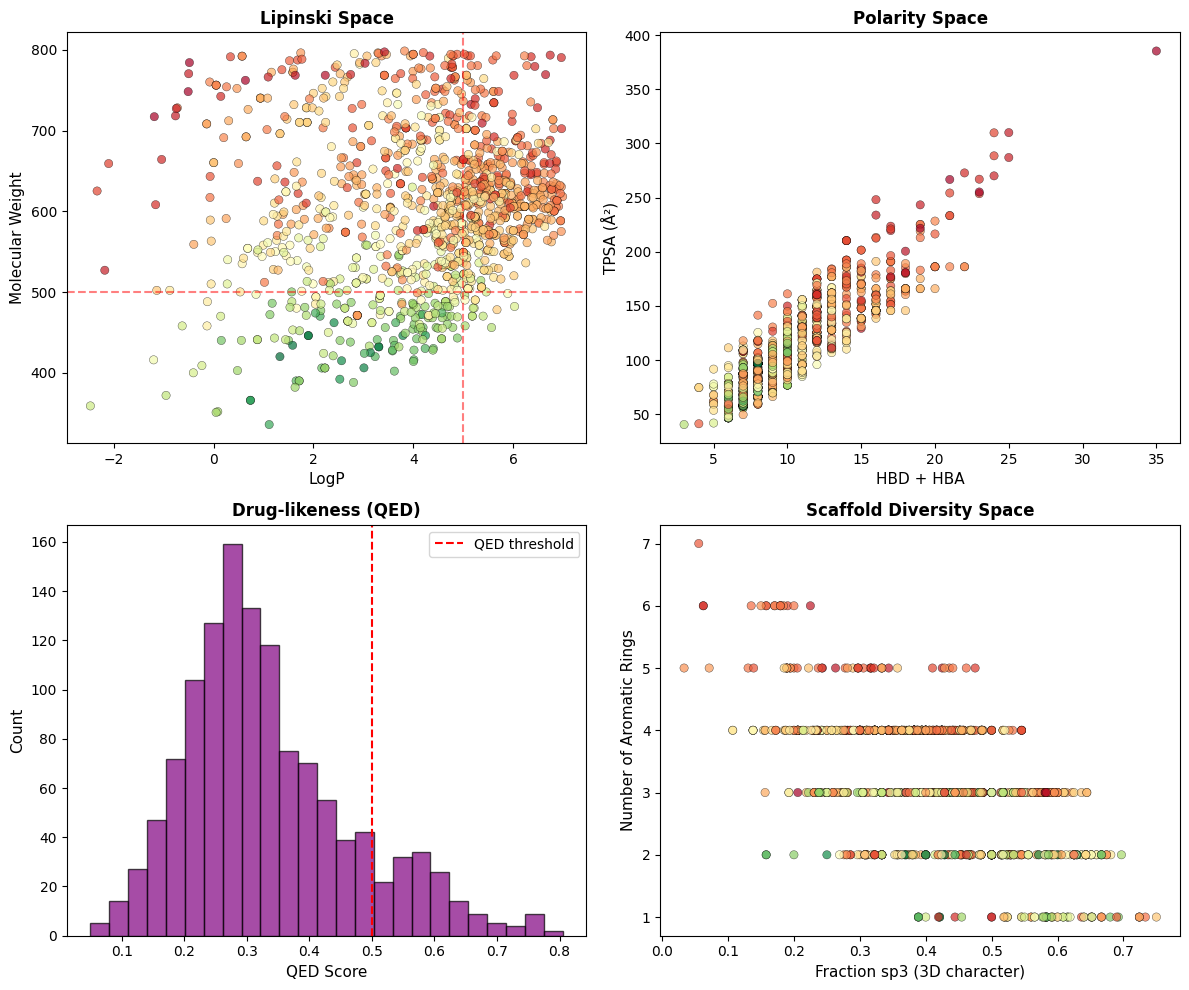

In [49]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# ============================================================
# CHEMICAL SPACE VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# MW vs LogP (Lipinski space)
ax1 = axes[0, 0]
scatter = ax1.scatter(df['ClogP'], df['MW'],
                      c=df['QED'],
                      cmap='RdYlGn',
                      alpha=0.7, edgecolor='k', linewidth=0.3)
ax1.axhline(y=500, color='red', linestyle='--', alpha=0.5, label='Lipinski MW')
ax1.axvline(x=5, color='red', linestyle='--', alpha=0.5, label='Lipinski LogP')
ax1.set_xlabel('LogP', fontsize=11)
ax1.set_ylabel('Molecular Weight', fontsize=11)
ax1.set_title('Lipinski Space', fontsize=12, fontweight='bold')

# TPSA vs HBD+HBA
ax2 = axes[0, 1]
df['HB_total'] = df['HBD'] + df['HBA']
scatter2 = ax2.scatter(df['HB_total'], df['TPSA'],
                        cmap='RdYlGn',
                        c=df['QED'],
                       alpha=0.7, edgecolor='k', linewidth=0.3)
ax2.set_xlabel('HBD + HBA', fontsize=11)
ax2.set_ylabel('TPSA (Å²)', fontsize=11)
ax2.set_title('Polarity Space', fontsize=12, fontweight='bold')

# QED distribution
ax3 = axes[1, 0]
ax3.hist(df['QED'], bins=25, edgecolor='black', alpha=0.7, color='purple')
ax3.axvline(x=0.5, color='red', linestyle='--', label='QED threshold')
ax3.set_xlabel('QED Score', fontsize=11)
ax3.set_ylabel('Count', fontsize=11)
ax3.set_title('Drug-likeness (QED)', fontsize=12, fontweight='bold')
ax3.legend()

ax4 = axes[1, 1]  # e.g., bottom-right panel

scatter = ax4.scatter(df['FractionCsp3'],
                      df['NumAromaticRings'],
                      c=df['QED'],
                      cmap='RdYlGn',
                      alpha=0.7, edgecolor='k', linewidth=0.3)

ax4.set_xlabel('Fraction sp3 (3D character)', fontsize=11)
ax4.set_ylabel('Number of Aromatic Rings', fontsize=11)
ax4.set_title('Scaffold Diversity Space', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/candidates_chemical_space.png', dpi=300, bbox_inches='tight')
plt.show()